# Retina accross species comparison

## Setup

### Import libraries:

In [ ]:
## Set the right working directory:
import sys
sys.path.append('/home/jovyan/projects/cellcount/')
import os
print(os.getcwd())
os.chdir('/home/jovyan/projects/cellcount')
print(os.getcwd())

import pandas as pd
import numpy as np
#import scipy as sc
import matplotlib.pyplot as plt
# from matplotlib.ticker import MultipleLocator
# from matplotlib import gridspec
%matplotlib inline
#from math import floor

from utils import *

/home/jovyan
/home/jovyan/projects/cellcount


### Define paths:

In [2]:
path2kdrive = "/home/jovyan/kDrive"
path2mainfolder = os.path.join(path2kdrive, "cellcount/data/project_Aa_Hr_Fovea")
path2plots = os.path.join(path2mainfolder, "plots")
path2pickle = os.path.join(path2mainfolder, "pickled_data")
print(f"Plots will be saved in {path2plots}")

Plots will be saved in /home/jovyan/kDrive/cellcount/data/project_Aa_Hr_Fovea/plots


### Define environment variables:

In [3]:
FIGPARAMS = {
    'labelsize': 10,
    'fontsize': 12,
    'legendfontsize': 10,
    'legendtitlesize': 12,
}

SPECIES_NAMES = {
    'Hr11': 'Barn Swallow (Hr11)',
    'Hr21': 'Barn Swallow (Hr21)',
    'Cj22': 'Japanese Quail (Cj22)',
    'Aa14': 'Common Swift (Aa14)',
    'Du26': 'Northern House Martin (Du26)',
    'Mc12': 'Grey Wagtail (Mc12)'
}

### Choose parameters (species, region):

In [ ]:
species_list = ['Hr21', 'Aa14']
region = 'NR1-NR4'

save_final_data = False

## Import and prepare data

### TESTING: import data for a single species and region

In [5]:
species = 'Hr21'
region = 'NR1-NR4'
# Load data from pickled file:
pickle_filename = f"GC_{species}_{region}.pickle"
df_gc_areas = pd.read_pickle(os.path.join(path2pickle, pickle_filename))

In [6]:
df_gc_areas

,x,x_unfold,gc_area,diameters
788,22291.921744,NaN,220.815,16.767540
26,10425.306460,10427.894308,211.860,16.424023
782,24899.115153,NaN,194.220,15.725412
829,12172.346078,NaN,183.600,15.289434
790,21528.890257,NaN,168.120,14.630688
...,...,...,...,...
776,19644.442435,NaN,8.295,3.249850
402,14381.140265,NaN,8.175,3.226257
395,16742.601445,NaN,7.845,3.160469
769,10864.951968,NaN,7.495,3.089163


### Import data for the specified two species the region

In [7]:
area_dict = {}
for species in species_list:
    # Load data from pickled file:
    pickle_filename = f"GC_{species}_{region}.pickle"
    df_gc_areas = pd.read_pickle(os.path.join(path2pickle, pickle_filename))
    area_dict[species] = list(df_gc_areas.gc_area)

area_dict.keys()

dict_keys(['Hr21', 'Aa14'])

## Plot data

In [16]:
def stacked_GC_distributions(areas_dict, area_thr, species_names=None, log_scale=True, path2save=None):
    '''
    - 
    '''
    
    species_list, areas_list = zip(*areas_dict.items())
    
    if species_list == ('Hr21', 'Cj22'):
        COLORS = ['#0169AF', '#EC8600']
    elif species_list == ('Hr21', 'Hr11'):
        COLORS = ['#0169AF', '#55B3F2']
    elif species_list == ('Hr21', 'Aa14'):
        COLORS = ['#1E72FA', '#F007F0']
    elif species_list == ('Aa14', 'Cj22'):
        COLORS = ['#00CC00', '#EC8600']
    elif species_list == ('Hr21', 'Aa14', 'Du26'):
        COLORS = ['#0169AF', '#00CC00', '#EC8600']
    elif species_list == ('Hr21', 'Mc12', 'Cj22'):
        COLORS = ['#0169AF', '#00CC00', '#EC8600']            

    fig, ax = plt.subplots(figsize=(15, 7))
    output_hist = ax.hist(areas_list, np.arange(0, 300, 5), log=log_scale, density=False, histtype='bar', rwidth=1, color=COLORS, zorder=3)

    for id, areas in enumerate(areas_list):
        percent_gt_thr = round(len([True for i in areas if i > area_thr]) / len(areas) * 100) 
        textstr = '\n'.join((
        f'{species_names[species_list[id]]}: \n',
        f'total number of GCs: {len(areas)}',
        f'median area of a GC: {np.median(areas): .0f} $\mu$m$^2$',
        #f'mean area of a GC: {np.mean(areas): .0f} $\mu$m$^2$',
        f'proportion of GCs $\geq {area_thr} \ \mu$m$^2$: {percent_gt_thr:.0f} %'
        ))
        if len(areas_list) == 2:
            text_fontsize = 18
            hspace_btw_textboxes = 0.4
            textboxes_left_padding = 0.2
        else:
            text_fontsize = 12
            hspace_btw_textboxes = 0.3
            textboxes_left_padding = 0.14

        ax.text(
            textboxes_left_padding + id*hspace_btw_textboxes,
            0.95,
            textstr,
            transform=ax.transAxes,
            fontsize=text_fontsize,
            verticalalignment='top',
            horizontalalignment='left',
            color=COLORS[id]
        )

    ax.set_ylabel('counts', fontsize=20)
    ax.set_xlabel(r'GC area / $\mu$m$^2$', fontsize=20)
    
    if log_scale:
        ax.set_ylim(ymax=1e3)
    else:
        ax.set_ylim(ymax=150)

    # change the fontsize:
    ax.tick_params(axis='x', labelsize=20)
    ax.tick_params(axis='y', labelsize=20)

    ax.set_title("GC size distributions in region NR1-NR4 for Hr21 vs Aa14")

    plt.grid()

    if path2save is not None:
        print("saving plot")
        fig.savefig(path2save, facecolor='white')
 
    return output_hist

saving plot


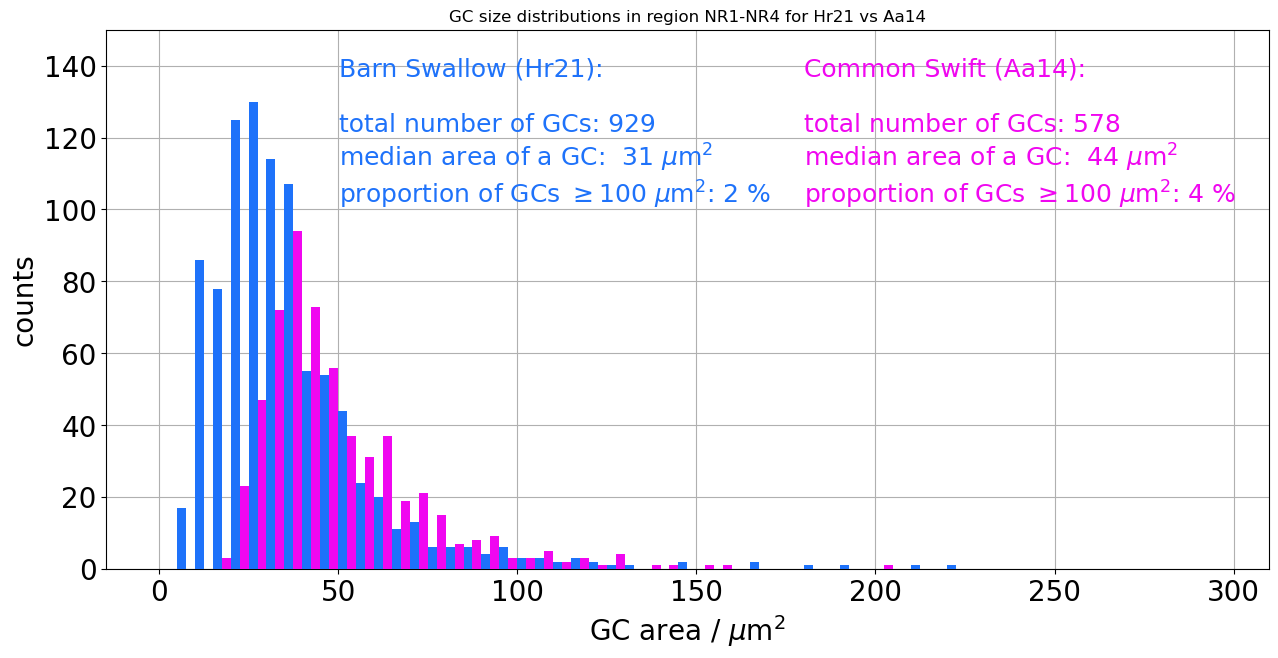

In [17]:
if save_final_data == True:
    path2save = os.path.join(path2plots, f"GC_sizes_distribution_{species_list[0]}_vs_{species_list[1]}.png")
else:
    path2save = None

h = stacked_GC_distributions(
    area_dict,
    area_thr=100,
    species_names=SPECIES_NAMES,
    log_scale=False,
    path2save=path2save
)